# Tutorial 6.1: Control-oriented building modelling and simulation

This tutorial turns a continuous thermal balance into a small discrete model that can be simulated repeatedly. The controller model is deliberately simpler than the supplied reference plant.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. implement a discrete $1R1C$ temperature update;
2. simulate a free temperature trajectory;
3. explain how $R$, $C$ and the sampling interval affect the response; and
4. distinguish a controller model from a reference plant.

## Indicative schedule

- set-up and energy balance: 15 minutes;
- discrete model and rollout: 25 minutes;
- step-response experiments: 25 minutes;
- comparison with the reference plant: 20 minutes;
- discussion: 5 minutes.

## 1. Set-up and operating conditions

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from course_utils.reference_building import TwoStateReferencePlant

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    raise FileNotFoundError("Run this notebook from the repository root.")

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})

,outdoor_temperature_c,solar_irradiance_w_m2,internal_gains_kw,occupancy,comfort_min_c,comfort_max_c,base_load_kw,pv_available_kw,import_price_gbp_per_kwh,export_price_gbp_per_kwh
timestamp,,,,,,,,,,
2025-02-03 00:00:00,6.53872,0.0,1.0,1,20.0,23.0,0.60000,0.0,0.18,0.08
2025-02-03 00:30:00,5.90019,0.0,1.0,1,20.0,23.0,0.60136,0.0,0.18,0.08
2025-02-03 01:00:00,5.97319,0.0,1.0,1,20.0,23.0,0.60536,0.0,0.18,0.08
2025-02-03 01:30:00,5.81084,0.0,1.0,1,20.0,23.0,0.61172,0.0,0.18,0.08
2025-02-03 02:00:00,5.28183,0.0,1.0,1,20.0,23.0,0.62000,0.0,0.18,0.08


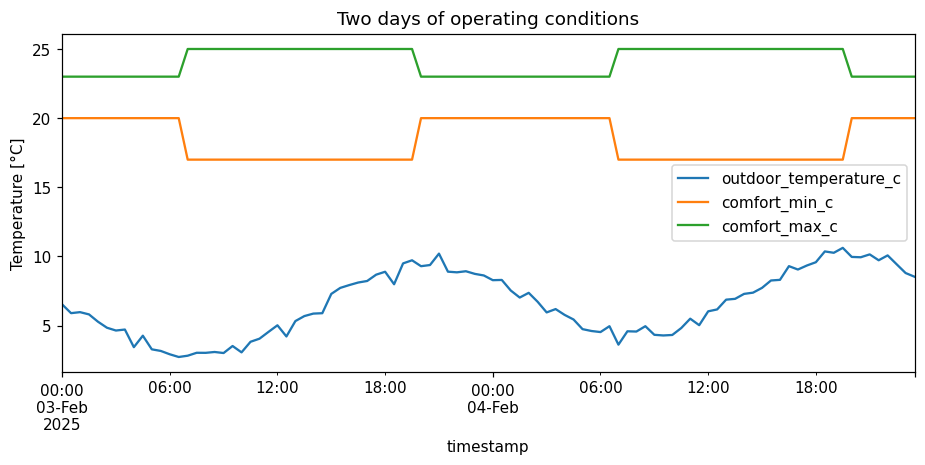

In [2]:
conditions = pd.read_csv(
    ROOT / "data" / "reference_building" / "operation_conditions.csv",
    index_col="timestamp",
    parse_dates=True,
).iloc[: 2 * 48]

display(conditions.head())
conditions[["outdoor_temperature_c", "comfort_min_c", "comfort_max_c"]].plot()
plt.ylabel("Temperature [°C]")
plt.title("Two days of operating conditions")
plt.show()

## 2. Task 1 — one discrete $1R1C$ update

For resistance $R$ in K/kW, capacitance $C$ in kWh/K and interval length $\Delta t$ in hours:

$$
T_{k+1}=T_k+\frac{\Delta t}{C}\left(\frac{T_{o,k}-T_k}{R}+q_{th,k}\right)
$$

Heating is positive. The input $q_{th,k}$ is useful heat delivered to the zone, not electrical power.

In [3]:
def one_r_one_c_step(
    indoor_temperature_c,
    outdoor_temperature_c,
    delivered_heat_kw,
    resistance_k_per_kw,
    capacitance_kwh_per_k,
    step_hours,
):
    heat_loss_kw = (outdoor_temperature_c - indoor_temperature_c) / resistance_k_per_kw
    temperature_change_c = step_hours * (heat_loss_kw + delivered_heat_kw) / capacitance_kwh_per_k
    return indoor_temperature_c + temperature_change_c

In [4]:
example_next_temperature = one_r_one_c_step(
    indoor_temperature_c=20.0,
    outdoor_temperature_c=5.0,
    delivered_heat_kw=4.0,
    resistance_k_per_kw=5.4,
    capacitance_kwh_per_k=4.0,
    step_hours=0.5,
)
print(f"Next temperature: {example_next_temperature:.3f} °C")

Next temperature: 20.153 °C


## 3. Task 2 — free rollout

A **free rollout** starts from one observed initial temperature and then feeds each model prediction into the next update. No later indoor-temperature measurements are used to reset the model. This is also called a **recursive multi-step** simulation.

Use your one-step update repeatedly over the two-day input series. Start from the same indoor temperature in both cases and compare (i) no heating with (ii) a prescribed morning and evening heating schedule under the same outdoor-temperature conditions. Each predicted indoor temperature becomes the initial condition for the next interval; the model is not reset from measurements.

The upper panel compares the two simulated indoor-temperature trajectories with outdoor temperature. The lower panel shows the useful-heat schedule used in the scheduled-heating case.

In [5]:
def simulate_one_r_one_c(
    outdoor_temperature_c,
    delivered_heat_kw,
    initial_temperature_c,
    resistance_k_per_kw,
    capacitance_kwh_per_k,
    step_hours,
):
    temperatures = [float(initial_temperature_c)]
    for outdoor, heat in zip(outdoor_temperature_c.iloc[:-1], delivered_heat_kw.iloc[:-1]):
        temperatures.append(
            one_r_one_c_step(
                temperatures[-1], outdoor, heat,
                resistance_k_per_kw, capacitance_kwh_per_k, step_hours
            )
        )
    return pd.Series(temperatures, index=outdoor_temperature_c.index, name="indoor_temperature_c")

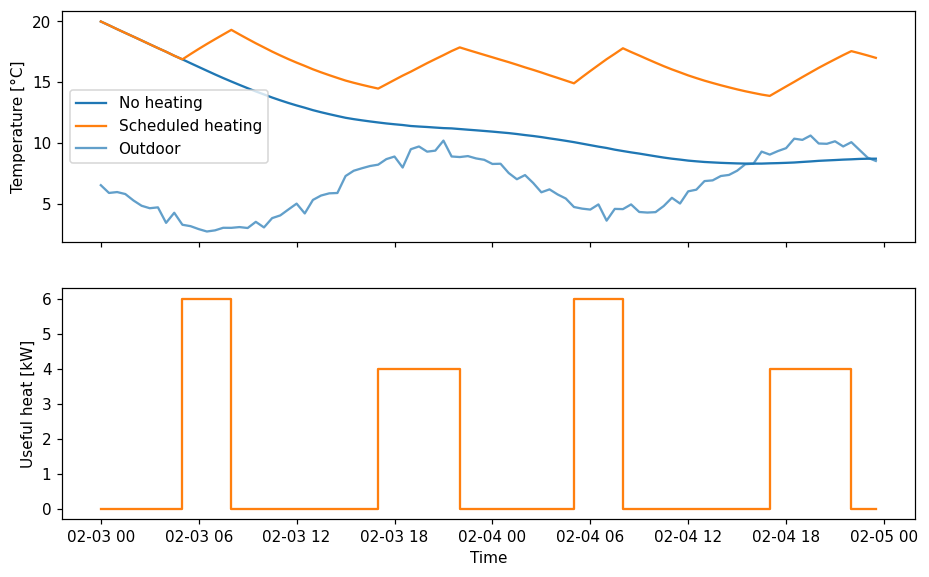

In [6]:
step_hours = 0.5
controller_resistance = 5.4
controller_capacitance = 4.0

heat_schedule = pd.Series(0.0, index=conditions.index)
heat_schedule.loc[(conditions.index.hour >= 5) & (conditions.index.hour < 8)] = 6.0
heat_schedule.loc[(conditions.index.hour >= 17) & (conditions.index.hour < 22)] = 4.0

temperature_no_heat = simulate_one_r_one_c(
    conditions["outdoor_temperature_c"],
    pd.Series(0.0, index=conditions.index),
    20.0,
    controller_resistance,
    controller_capacitance,
    step_hours,
)
temperature_scheduled = simulate_one_r_one_c(
    conditions["outdoor_temperature_c"],
    heat_schedule,
    20.0,
    controller_resistance,
    controller_capacitance,
    step_hours,
)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
axes[0].plot(temperature_no_heat, label="No heating", color = 'tab:blue')
axes[0].plot(temperature_scheduled, label="Scheduled heating", color = 'tab:orange')
axes[0].plot(conditions["outdoor_temperature_c"], label="Outdoor", alpha=0.7)
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
axes[1].step(heat_schedule.index, heat_schedule, where="post", color = 'tab:orange')
axes[1].set_ylabel("Useful heat [kW]")
axes[1].set_xlabel("Time")
plt.show()

## 4. Task 3 — parameter experiments

This is a new, idealised sensitivity experiment rather than an exact repetition of Task 2. The outdoor temperature is held at 5 °C, useful heating is held at 5 kW, and every simulation starts at 18 °C. The left panel varies $R$ while holding $C$ fixed; the right panel varies $C$ while holding $R$ fixed. Each line is a free rollout of indoor temperature over 48 hours.

Changing one parameter at a time isolates its effect. Predict how the curves should differ before running the cell.

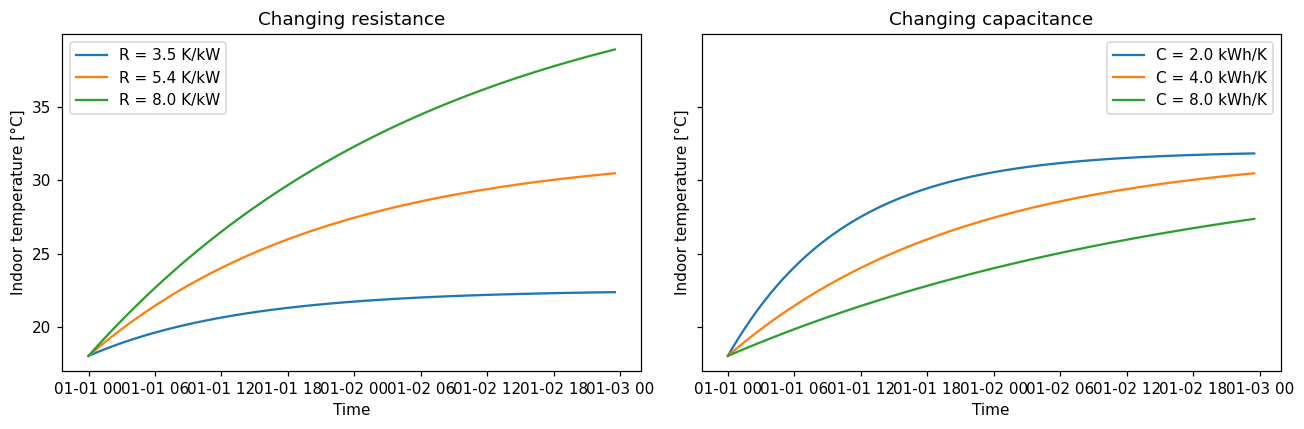

In [7]:
experiment_index = pd.date_range("2025-01-01", periods=96, freq="30min")
experiment_outdoor = pd.Series(5.0, index=experiment_index)
experiment_heat = pd.Series(5.0, index=experiment_index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for resistance in [3.5, 5.4, 8.0]:
    response = simulate_one_r_one_c(
        experiment_outdoor, experiment_heat, 18.0,
        resistance, controller_capacitance, step_hours
    )
    axes[0].plot(response, label=f"R = {resistance} K/kW")
for capacitance in [2.0, 4.0, 8.0]:
    response = simulate_one_r_one_c(
        experiment_outdoor, experiment_heat, 18.0,
        controller_resistance, capacitance, step_hours
    )
    axes[1].plot(response, label=f"C = {capacitance} kWh/K")
for axis in axes:
    axis.set_xlabel("Time")
    axis.set_ylabel("Indoor temperature [°C]")
    axis.legend()
axes[0].set_title("Changing resistance")
axes[1].set_title("Changing capacitance")
plt.tight_layout()
plt.show()

## 5. Supplied reference plant

The reference plant has separate indoor-air and fabric temperatures, variable COP, ventilation, solar gains, internal gains and reproducible noise. Its `reset` and `step` interface is kept separate from the controller model so that it can later be replaced by BOPTEST.

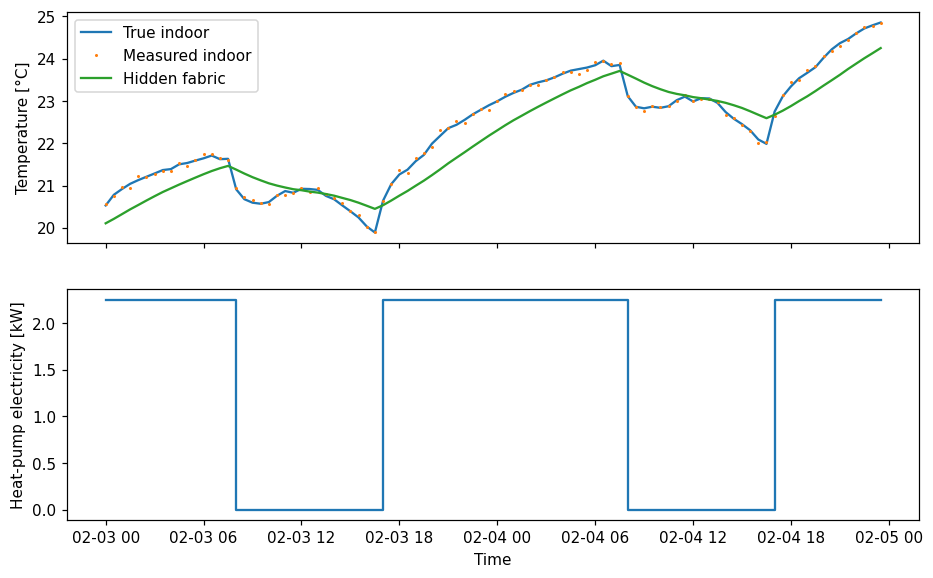

In [8]:
plant = TwoStateReferencePlant(
    step_hours=0.5,
    measurement_noise_std_c=0.05,
    process_noise_std_c=0.01,
    random_state=12,
)
measurement = plant.reset(20.0, 20.0)
records = []

for timestamp, row in conditions.iterrows():
    modulation = 0.45 if (timestamp.hour < 8 or timestamp.hour >= 17) else 0.0
    result = plant.step(
        modulation,
        row["outdoor_temperature_c"],
        row["solar_irradiance_w_m2"],
        row["internal_gains_kw"],
    )
    records.append({"timestamp": timestamp, **result, "modulation": modulation})

reference_results = pd.DataFrame(records).set_index("timestamp")
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
axes[0].plot(reference_results["indoor_temperature_true_c"], label="True indoor")
axes[0].plot(reference_results["indoor_temperature_measured_c"], ".", ms=2, label="Measured indoor")
axes[0].plot(reference_results["fabric_temperature_c"], label="Hidden fabric")
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
axes[1].step(reference_results.index, reference_results["heat_pump_electric_kw"], where="post")
axes[1].set_ylabel("Heat-pump electricity [kW]")
axes[1].set_xlabel("Time")
plt.show()

## Discussion

1. Which parameter mainly changes the steady temperature response?
2. Which parameter mainly changes response speed?
3. Why does the measured reference-plant temperature look less smooth?
4. Why should the optimisation model remain simpler than the reference plant?